
Test Accuracy: 0.6840232230481466
Test Macro F1: 0.4643761961760167

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.05      0.29      0.09       677
      Backdoor       0.04      0.28      0.06       583
           DoS       0.34      0.13      0.19      4089
      Exploits       0.77      0.61      0.68     11132
       Fuzzers       0.18      0.37      0.24      6062
       Generic       1.00      0.96      0.98     18871
        Normal       0.88      0.68      0.77     37000
Reconnaissance       0.88      0.82      0.85      3496
     Shellcode       0.19      0.60      0.28       378
         Worms       0.53      0.48      0.50        44

      accuracy                           0.68     82332
     macro avg       0.48      0.52      0.46     82332
  weighted avg       0.80      0.68      0.73     82332



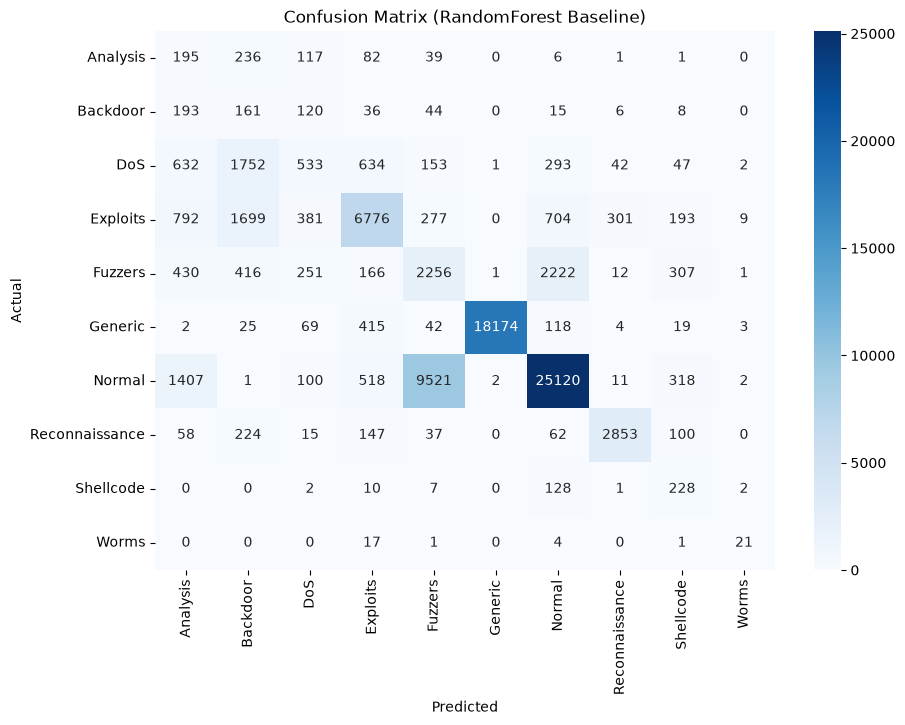

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# -----------------------------
# Load UNSW testing set
# -----------------------------
df_test = pd.read_csv("UNSW_NB15_testing-set.csv")

# Separate features and target
X_test = df_test.drop(columns=["label", "attack_cat"], errors="ignore")
y_test = df_test["attack_cat"]

# Derived features (must match training!)
X_test["byte_ratio"] = X_test["sbytes"] / (X_test["dbytes"] + 1)
X_test["pkt_size_ratio"] = X_test["smean"] / (X_test["dmean"] + 1)
X_test["traffic_rate"] = X_test["sload"] / (X_test["dload"] + 1)
X_test["ttl_diff"] = X_test["sttl"] - X_test["dttl"]
X_test["srv_dst_ratio"] = X_test["ct_srv_dst"] / (X_test["ct_dst_src_ltm"] + 1)

# -----------------------------
# Load preprocessor + label encoder + trained model
# -----------------------------
preprocessor = joblib.load("preprocessor_full.pkl")
label_encoder = joblib.load("label_encoder_full.pkl")
rf_model = joblib.load("random_forest_multi_smote.pkl")

# -----------------------------
# Preprocess test set
# -----------------------------
X_test_proc = preprocessor.transform(X_test)

# -----------------------------
# Predictions
# -----------------------------
y_pred_encoded = rf_model.predict(X_test_proc)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# -----------------------------
# Evaluation
# -----------------------------
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (RandomForest Baseline)")
plt.show()
